# Question 01

**Imports**

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log, blob_dog
from mpl_toolkits.mplot3d import Axes3D

**Detecting blobs using Laplacian of Gaussian**

In [4]:
im=cv.imread('/content/drive/MyDrive/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray=cv.cvtColor(im,cv.COLOR_BGR2GRAY)

# LoG method to detect blobs
blobs_log=blob_log(gray,max_sigma=30,num_sigma=10,threshold=0.1)
blobs_log[:,2]=blobs_log[:,2]*np.sqrt(2)

# Draw the detected circles on the image for LoG
im_log=im.copy()
for blob in blobs_log:
  y,x,r=blob
  cv.circle(im_log,(int(x),int(y)),int(r),(255,0,0),2)

# Finding the largest circle
if len(blobs_log) > 0:
  largest_blob_log=max(blobs_log,key=lambda b: b[2])
  x_largest_log,y_largest_log,radius_largest_log=largest_blob_log
  print(f"Largest circle using LoG: Center=({x_largest_log: .2f},{y_largest_log:.2f}),Radius={radius_largest_log: .2f}")






Largest circle using LoG: Center=( 0.00,234.00),Radius= 42.43


**Detecting blobs using Difference of Gaussian**

In [5]:
blobs_dog = blob_dog(gray, max_sigma=30, threshold=0.1)

im_dog = im.copy()
for blob in blobs_dog:
    y, x, r = blob
    cv.circle(im_dog, (int(x), int(y)), int(r), (0, 255, 0), 2)

if len(blobs_dog) > 0:
    largest_blob_dog = max(blobs_dog, key=lambda b: b[2])
    x_largest_dog, y_largest_dog, radius_largest_dog = largest_blob_dog
    print(f"Largest circle using DoG: Center=({x_largest_dog:.2f}, {y_largest_dog:.2f}), Radius={radius_largest_dog:.2f}")
else:
    print("No circles detected using DoG.")


Largest circle using DoG: Center=(0.00, 237.00), Radius=26.84


**Display the images with detected circles**

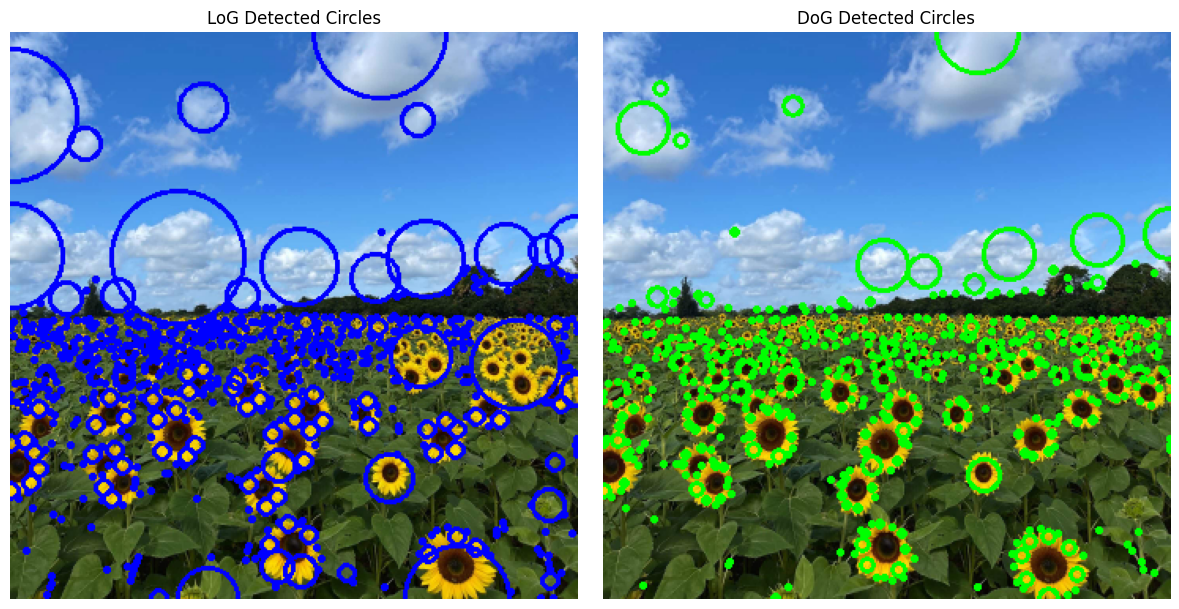

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv.cvtColor(im_log, cv.COLOR_BGR2RGB))
axes[0].set_title('LoG Detected Circles')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(im_dog, cv.COLOR_BGR2RGB))
axes[1].set_title('DoG Detected Circles')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Plot the largest blobs as 3D matrix images**

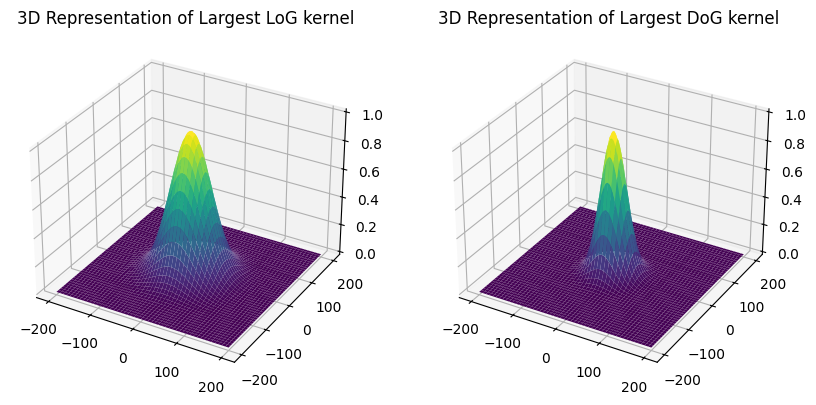

In [7]:
if len(blobs_log) > 0:
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(121, projection='3d')
    x = np.linspace(-200, 200, 400)
    y = np.linspace(-200, 200, 400)
    X, Y = np.meshgrid(x, y)
    Z = np.exp(-(X**2 + Y**2) / (2 * (radius_largest_log**2)))
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title('3D Representation of Largest LoG kernel')

if len(blobs_dog) > 0:
    ax = fig.add_subplot(122, projection='3d')
    x = np.linspace(-200, 200, 400)
    y = np.linspace(-200, 200, 400)
    X, Y = np.meshgrid(x, y)
    Z = np.exp(-(X**2 + Y**2) / (2 * (radius_largest_dog**2)))
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title('3D Representation of Largest DoG kernel')

plt.show()

**Using LoG and DoG to detect local mimima**

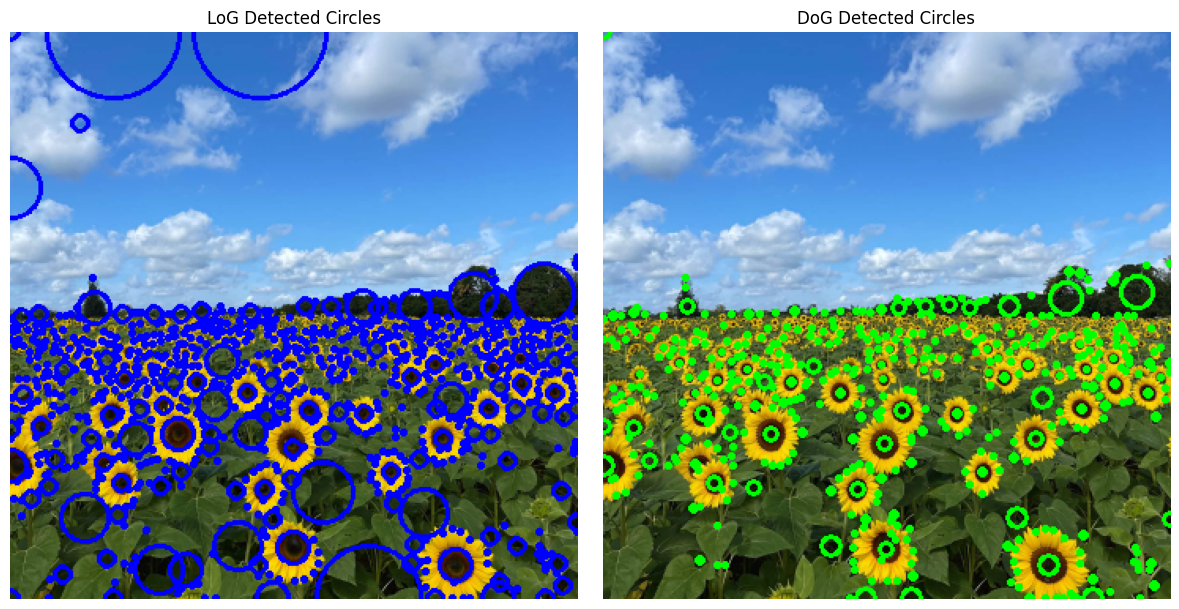

Largest circle using LoG: Center=(0.00, 65.00), Radius=42.43
Largest circle using DoG: Center=(165.00, 338.00), Radius=10.49


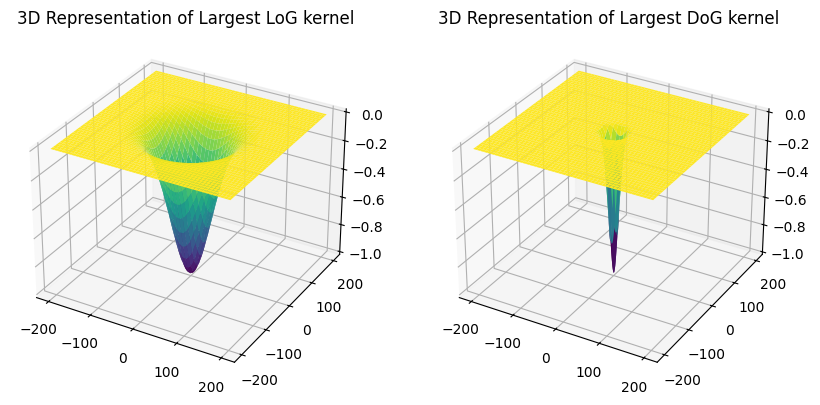

In [10]:
im=cv.imread('/content/drive/MyDrive/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
# Invert the image to focus on black blobs
im_inverted=cv.bitwise_not(im)

gray=cv.cvtColor(im_inverted,cv.COLOR_BGR2GRAY)

# Detect blobs using Laplacian of Gaussian (LoG) method
blobs_log = blob_log(gray, max_sigma=30, num_sigma=10, threshold=0.1)
blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)  # Convert sigma to radius

# Detect blobs using Difference of Gaussian (DoG) method
blobs_dog = blob_dog(gray, max_sigma=30, threshold=0.1)

# Draw the detected circles on the image for LoG
im_log = im.copy()
for blob in blobs_log:
    y, x, r = blob
    cv.circle(im_log, (int(x), int(y)), int(r), (255, 0, 0), 2)

# Draw the detected circles on the image for DoG
im_dog = im.copy()
for blob in blobs_dog:
    y, x, r = blob
    cv.circle(im_dog, (int(x), int(y)), int(r), (0, 255, 0), 2)

# Display the images with detected circles
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv.cvtColor(im_log, cv.COLOR_BGR2RGB))
axes[0].set_title('LoG Detected Circles')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(im_dog, cv.COLOR_BGR2RGB))
axes[1].set_title('DoG Detected Circles')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Find the largest circle for LoG
if len(blobs_log) > 0:
    largest_blob_log = max(blobs_log, key=lambda b: b[2])
    x_largest_log, y_largest_log, radius_largest_log = largest_blob_log
    print(f"Largest circle using LoG: Center=({x_largest_log:.2f}, {y_largest_log:.2f}), Radius={radius_largest_log:.2f}")
else:
    print("No circles detected using LoG.")

# Find the largest circle for DoG
if len(blobs_dog) > 0:
    largest_blob_dog = max(blobs_dog, key=lambda b: b[2])
    x_largest_dog, y_largest_dog, radius_largest_dog = largest_blob_dog
    print(f"Largest circle using DoG: Center=({x_largest_dog:.2f}, {y_largest_dog:.2f}), Radius={radius_largest_dog:.2f}")
else:
    print("No circles detected using DoG.")

# Plot the largest blobs as 3D matrix images
if len(blobs_log) > 0:
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(121, projection='3d')
    x = np.linspace(-200, 200, 400)
    y = np.linspace(-200, 200, 400)
    X, Y = np.meshgrid(x, y)
    Z = -np.exp(-(X**2 + Y**2) / (2 * (radius_largest_log**2)))
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title('3D Representation of Largest LoG kernel')

if len(blobs_dog) > 0:
    ax = fig.add_subplot(122, projection='3d')
    x = np.linspace(-200, 200, 400)
    y = np.linspace(-200, 200, 400)
    X, Y = np.meshgrid(x, y)
    Z = -np.exp(-(X**2 + Y**2) / (2 * (radius_largest_dog**2)))
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title('3D Representation of Largest DoG kernel')

plt.show()




**Comparing Detected Blobs at Different Sigma Values**

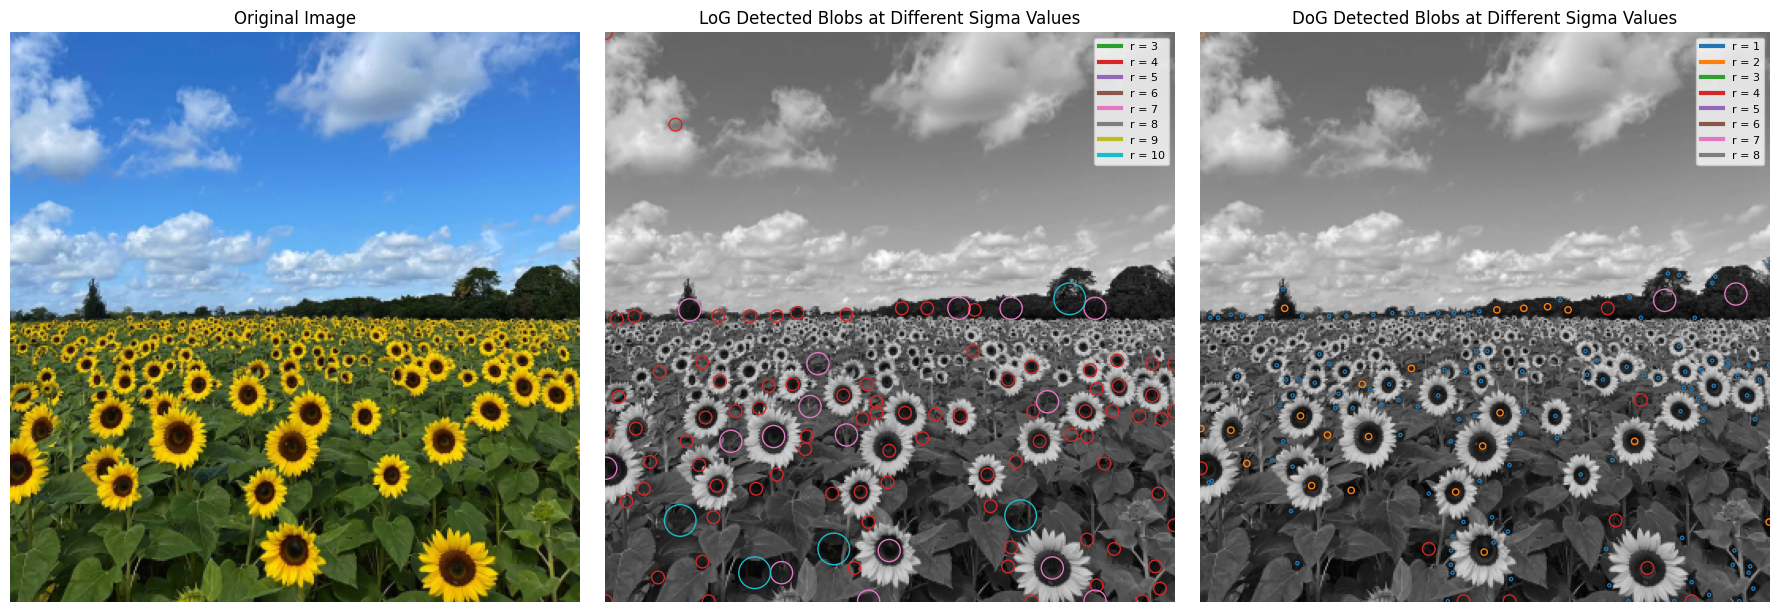

In [14]:


import matplotlib.colors as mcolors
fig,axes=plt.subplots(1,3,figsize=(18,6))

# Original image
axes[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Draw the detected circles on the image for LoG with different colors for each radius
im_log_gray=cv.cvtColor(im,cv.COLOR_BGR2GRAY) / 255
colors=list(mcolors.TABLEAU_COLORS)
patches_log=[]
labels_log=[]

for r in range(3,11):
  sigma=r/1.414
  current_blobs_log=[blob for blob in blobs_log if int(blob[2] / np.sqrt(2))==r]
  for blob in current_blobs_log:
    y,x,_=blob
    c=plt.Circle((x, y), sigma * 1.414, color=colors[r - 1], linewidth=1, fill=False)
    axes[1].add_patch(c)
  patches_log.append(plt.Line2D([0], [0], color=colors[r - 1], linewidth=3))
  labels_log.append(f'r = {r}')
axes[1].imshow(im_log_gray, cmap='gray')
axes[1].set_title('LoG Detected Blobs at Different Sigma Values')
axes[1].axis('off')
axes[1].legend(patches_log, labels_log, loc='best', fontsize=8)

# Draw the detected circles on the image for DoG with different colors for each radius
im_dog_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY) / 255
patches_dog = []
labels_dog = []

for r in range(1, 9):
    sigma = r / 1.414
    current_blobs_dog = [blob for blob in blobs_dog if int(blob[2] / np.sqrt(2)) == r]
    for blob in current_blobs_dog:
        y, x, _ = blob
        c = plt.Circle((x, y), sigma * 1.414, color=colors[r - 1], linewidth=1, fill=False)
        axes[2].add_patch(c)
    patches_dog.append(plt.Line2D([0], [0], color=colors[r - 1], linewidth=3))
    labels_dog.append(f'r = {r}')
axes[2].imshow(im_dog_gray, cmap='gray')
axes[2].set_title('DoG Detected Blobs at Different Sigma Values')
axes[2].axis('off')
axes[2].legend(patches_dog, labels_dog, loc='best', fontsize=8)

plt.tight_layout()
plt.show()





In [15]:
# Find the largest circle for LoG
if len(blobs_log) > 0:
    largest_blob_log = max(blobs_log, key=lambda b: b[2])
    x_largest_log, y_largest_log, radius_largest_log = largest_blob_log
    print(f"Largest circle using LoG: Center=({x_largest_log:.2f}, {y_largest_log:.2f}), Radius={radius_largest_log:.2f}")
else:
    print("No circles detected using LoG.")

# Find the largest circle for DoG
if len(blobs_dog) > 0:
    largest_blob_dog = max(blobs_dog, key=lambda b: b[2])
    x_largest_dog, y_largest_dog, radius_largest_dog = largest_blob_dog
    print(f"Largest circle using DoG: Center=({x_largest_dog:.2f}, {y_largest_dog:.2f}), Radius={radius_largest_dog:.2f}")
else:
    print("No circles detected using DoG.")


Largest circle using LoG: Center=(0.00, 65.00), Radius=42.43
Largest circle using DoG: Center=(165.00, 338.00), Radius=10.49


# Question 02

**Generating noisy point set**

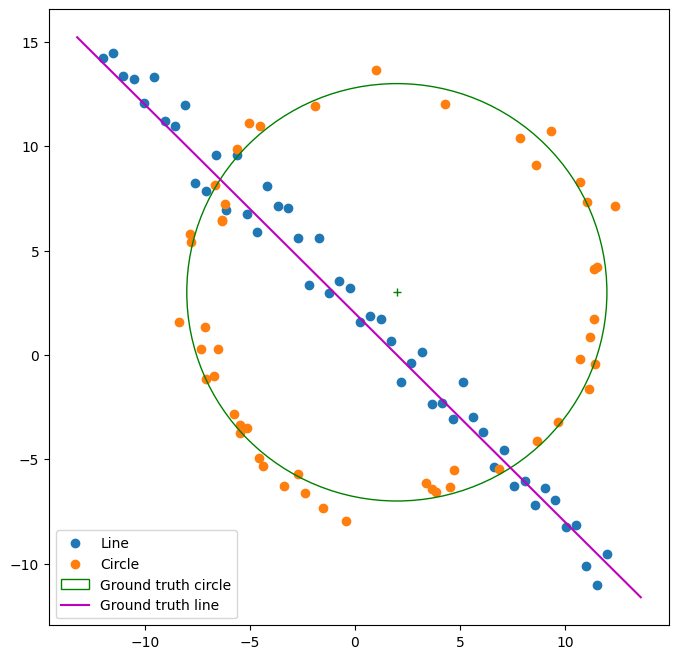

In [16]:
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import numpy as np
#import tikzplotlib

# Set random seed
np.random.seed(0)

# Constants
N = 100
half_n = N // 2

# Parameters
r = 10
x0_gt, y0_gt = 2, 3
s = r / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

s, m, b = 1, -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')


circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

plt.legend()


**Line and Circle Fitting using RANSAC**

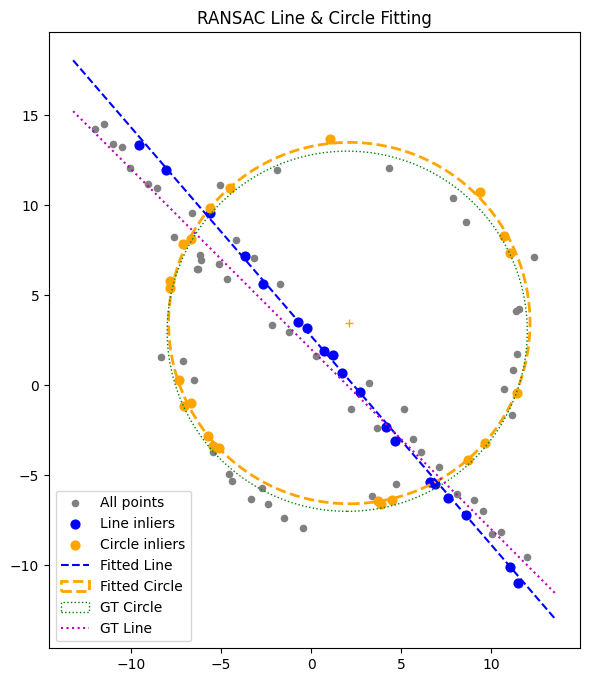

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from random import sample

np.random.seed(0)
N = 100
half_n = N // 2

# Circle points
r_true = 10
x0_true, y0_true = 2, 3
s = r_true / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x_circ = x0_true + (r_true + n) * np.cos(t)
y_circ = y0_true + (r_true + n) * np.sin(t)
X_circ = np.stack((x_circ, y_circ), axis=1)

# Line points
s, m, b = 1, -1, 2
x_line = np.linspace(-12, 12, half_n)
y_line = m * x_line + b + s * np.random.randn(half_n)
X_line = np.stack((x_line, y_line), axis=1)

# Combined dataset
X = np.vstack((X_circ, X_line))


# Distance to line ax + by + d = 0 (with ||[a, b]|| = 1)
def line_distance(params, X):
    a, b, d = params
    return np.abs(a * X[:, 0] + b * X[:, 1] + d)

# Fit line from 2 points
def fit_line_from_points(p1, p2):
    # Get the normal vector [a, b]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    norm = np.sqrt(dx**2 + dy**2)
    a = dy / norm
    b = -dx / norm
    d = -(a * p1[0] + b * p1[1])
    return np.array([a, b, d])


# RANSAC for line
def ransac_line(X, threshold=0.3, num_iter=100, min_inliers=30):
    best_model = None
    best_inliers = []

    for _ in range(num_iter):
        sample_points = sample(list(X), 2)
        model = fit_line_from_points(*sample_points)
        distances = line_distance(model, X)
        inliers = X[distances < threshold]
        if len(inliers) > len(best_inliers):
            best_model = model
            best_inliers = inliers

    return best_model, best_inliers


# Fit circle from 3 points using linear system
def fit_circle_from_3_points(p1, p2, p3):
    A = np.array([
        [p1[0], p1[1], 1],
        [p2[0], p2[1], 1],
        [p3[0], p3[1], 1]
    ])
    B = np.array([
        -(p1[0]**2 + p1[1]**2),
        -(p2[0]**2 + p2[1]**2),
        -(p3[0]**2 + p3[1]**2)
    ])
    coef = np.linalg.lstsq(A, B, rcond=None)[0]
    xc = -0.5 * coef[0]
    yc = -0.5 * coef[1]
    r = np.sqrt((coef[0]**2 + coef[1]**2) / 4 - coef[2])
    return np.array([xc, yc, r])


# Radial error to a circle
def circle_radial_error(params, X):
    xc, yc, r = params
    return np.abs(np.sqrt((X[:, 0] - xc)**2 + (X[:, 1] - yc)**2) - r)


# RANSAC for circle
def ransac_circle(X, threshold=0.3, num_iter=100, min_inliers=30):
    best_model = None
    best_inliers = []

    for _ in range(num_iter):
        sample_points = sample(list(X), 3)
        try:
            model = fit_circle_from_3_points(*sample_points)
        except np.linalg.LinAlgError:
            continue
        errors = circle_radial_error(model, X)
        inliers = X[errors < threshold]
        if len(inliers) > len(best_inliers):
            best_model = model
            best_inliers = inliers

    return best_model, best_inliers

# Run RANSAC for line
line_model, line_inliers = ransac_line(X, threshold=0.3)
line_a, line_b, line_d = line_model

# Remove line inliers
X_remain = np.array([pt for pt in X if not any(np.allclose(pt, li) for li in line_inliers)])


# Run RANSAC for circle
circle_model, circle_inliers = ransac_circle(X_remain, threshold=0.3)
xc, yc, rc = circle_model


# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# All points
ax.scatter(X[:, 0], X[:, 1], color='gray', s=20, label='All points')

# Line inliers
ax.scatter(line_inliers[:, 0], line_inliers[:, 1], color='blue', s=40, label='Line inliers')

# Circle inliers
ax.scatter(circle_inliers[:, 0], circle_inliers[:, 1], color='orange', s=40, label='Circle inliers')

# Line model
x_vals = np.array(ax.get_xlim())
y_vals = -(line_a * x_vals + line_d) / line_b
ax.plot(x_vals, y_vals, 'b--', label='Fitted Line')

# Circle model
circle_patch = plt.Circle((xc, yc), rc, color='orange', fill=False, linestyle='--', linewidth=2, label='Fitted Circle')
ax.add_patch(circle_patch)
ax.plot(xc, yc, '+', color='orange')

# Ground truth circle
gt_circle = plt.Circle((x0_true, y0_true), r_true, color='green', fill=False, linestyle=':', label='GT Circle')
ax.add_patch(gt_circle)

# Ground truth line
gt_y = m * x_vals + b
ax.plot(x_vals, gt_y, 'm:', label='GT Line')

ax.set_aspect('equal')
ax.legend()
ax.set_title('RANSAC Line & Circle Fitting')
plt.show()


# Question 04

In [6]:
import random

img1=cv.imread('/content/drive/MyDrive/img1.ppm')
img5=cv.imread('/content/drive/MyDrive/img4.ppm')

if img1 is None or img5 is None:
    print("Error: Unable to load images. Verify the file paths.")
    exit()




Error: Unable to load images. Verify the file paths.


**Detect and match SIFT features between two images**

In [6]:
sift = cv.SIFT_create()

# Detect keypoints and compute descriptor for both images
keypoints1, descriptors1 = sift.detectAndCompute(img1,None)
keypoints5, descriptors5 = sift.detectAndCompute(img5, None)

# Match features using FLANN-based matcher
flann_index_kdtree=1
index_params = dict(algorithm=flann_index_kdtree, trees=5)
search_params = dict(checks=100)
flann = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descriptors1, descriptors5, k=2)

# Apply Lowe's ratio test to filter good matches
confidence_level = 0.85  # Set confidence level for filtering matches
good_matches = []
for m, n in matches:
    if m.distance < confidence_level * n.distance:
        good_matches.append(m)


# Draw the filtered matches
img_matches = cv.drawMatches(img1, keypoints1, img5, keypoints5, good_matches, None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)



**Estimate the homography using RANSAC**

In [7]:
max_inliers=0
best_homography=None
threshold=2.0
iterations=2000

# Extract the matched points
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 2)
dst_pts = np.float32([keypoints5[m.trainIdx].pt for m in good_matches]).reshape(-1, 2)

for _ in range(iterations):
  # Randomly select 4 points
  idx=random.sample(range(len(good_matches)),4)
  src_sample=src_pts[idx]
  dst_sample=dst_pts[idx]

  # Compute homography matrix
  H, _ = cv.findHomography(src_sample,dst_sample,0)
  if H is None:
    continue

  # Project points using the homography
  projected_pts=cv.perspectiveTransform(src_pts.reshape(-1, 1, 2), H).reshape(-1, 2)

  # Calculate the Euclidean distance between projected points and actual points
  distances=np.linalg.norm(dst_pts - projected_pts,axis=1)

  # Count the number of inliers
  inliers=np.sum(distances < threshold)

  # Update the best homography if a higher number of inliers is found
  if inliers > max_inliers:
    max_inliers=inliers
    best_homgraphy=H

# Draw the inliers after RANSAC
if best_homography is not None:
   projected_pts = cv.perspectiveTransform(src_pts.reshape(-1, 1, 2), best_homography).reshape(-1, 2)
   inliers_mask = np.linalg.norm(dst_pts - projected_pts, axis=1) < threshold
   img_ransac_matches = cv.drawMatches(img1, keypoints1, img5, keypoints5, good_matches,None,matchesMask=inliers_mask.astype(int).tolist(), flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
else:
    print("RANSAC failed to compute a valid homography.")
    exit()






RANSAC failed to compute a valid homography.


**Stitch img1 onto img5**

In [1]:
if best_homography is not None:
  height,width,_ = img5.shape
  stitched_img=cv.warpPerspective(img1, best_homography, (width, height))

  plt.figure(figize=(10,10))
  plt.imshow(cv.cvtColor(img_ransac_matches,cv.COLOR_BGR2RGB))
  plt.title('Large View of Feature Matches with RANSAC')
  plt.axis('off')
  plt.show()

  # Create masks for blending the stitched image
  mask_stitched = (stitched_img > 0).astype(np.uint8)
  img5_masked = cv.bitwise_and(img5, img5, mask=cv.bitwise_not(mask_stitched[:, :, 0]))

  # Apply feather blending to reduce visible seams
  overlap_region = (mask_stitched[:, :, 0] & (img5[:, :, 0] > 0)).astype(np.float32)
  alpha = cv.GaussianBlur(overlap_region, (21, 21), 0) / 255.0

  # Weighted blend in overlapping regions
  blended_img = np.uint8(stitched_img * alpha[:, :, None] + img5_masked * (1 - alpha[:, :, None]))

  # Draw a light pink boundary to highlight the stitched area
  pink_boundary = (mask_stitched[:, :, 0] > 0).astype(np.uint8)
  contours, _ = cv.findContours(pink_boundary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
  cv.drawContours(blended_img, contours, -1, (255, 255, 0), 7)  # Light blue color with thicker line
else:
    print("Homography could not be computed.")
    exit()



NameError: name 'best_homography' is not defined

**Displaying the results**

In [2]:
# Display the images side by side
fig, axes = plt.subplots(1, 4, figsize=(24, 12))

# Display the first graffiti image
axes[0].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
axes[0].set_title('Graffiti Img 1')
axes[0].axis('off')

# Display the second graffiti image
axes[1].imshow(cv.cvtColor(img5, cv.COLOR_BGR2RGB))
axes[1].set_title('Graffiti Img 2')
axes[1].axis('off')

# Display the warped intermediate image
axes[2].imshow(cv.cvtColor(stitched_img, cv.COLOR_BGR2RGB))
axes[2].set_title('Warped Intermediate Image')
axes[2].axis('off')

# Display the final stitched image with highlighted boundary
axes[3].imshow(cv.cvtColor(blended_img, cv.COLOR_BGR2RGB))
axes[3].set_title('Stitched Image with Highlighted Boundary')
axes[3].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

**Homography matrix**

In [ ]:
# Print the homography matrix computed from the transformation
print("Computed Homography Matrix:\n", best_homography)

# Load the actual homography matrix from the dataset and compare
actual_homography_path = '/content/H1to4p'
actual_homography = np.loadtxt(actual_homography_path)
print("Actual Homography Matrix from Dataset:\n", actual_homography)

# Calculate the error between the computed and the actual homography matrices
homography_error = np.linalg.norm(actual_homography - best_homography)
print("Error between Computed and Actual Homography:\n", homography_error)

**Full Code**

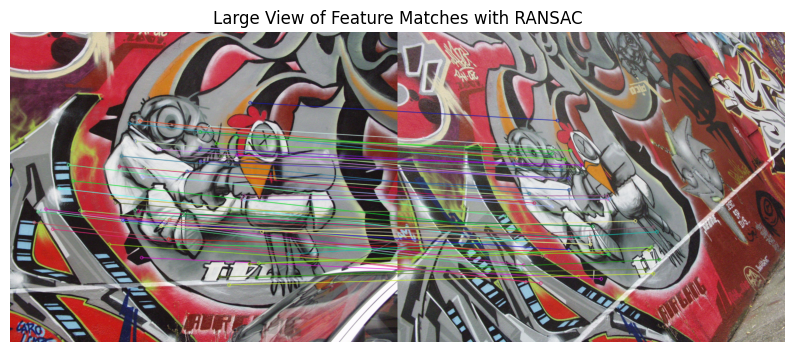

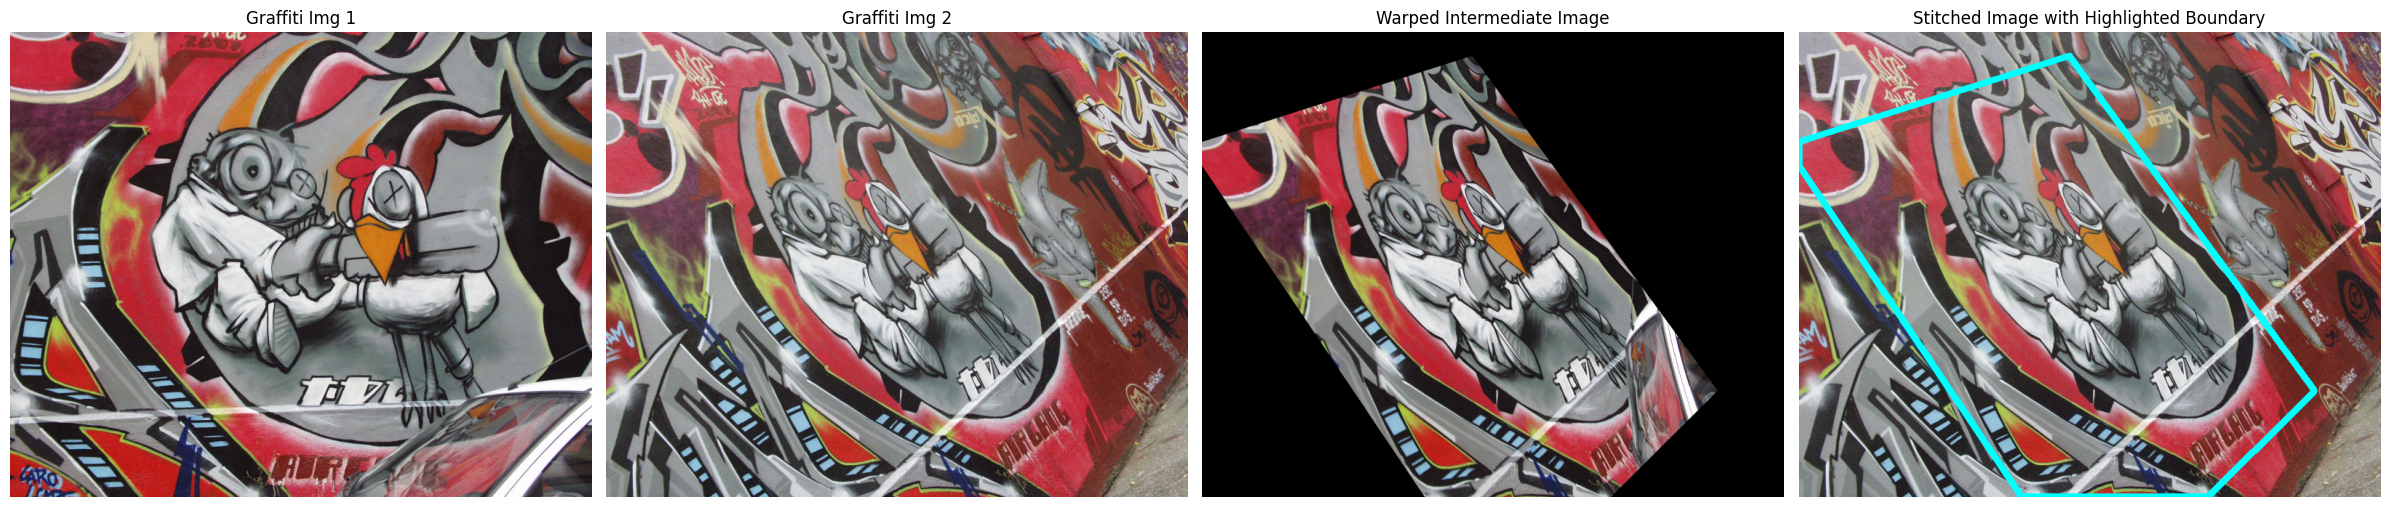

Computed Homography Matrix:
 [[ 6.40934900e-01  6.19857131e-01 -1.79431528e+01]
 [-1.42122102e-01  9.01963700e-01  1.56878755e+02]
 [ 4.14239845e-04 -1.15245877e-04  1.00000000e+00]]
Actual Homography Matrix from Dataset:
 [[ 6.6378505e-01  6.8003334e-01 -3.1230335e+01]
 [-1.4495500e-01  9.7128304e-01  1.4877420e+02]
 [ 4.2518504e-04 -1.3930359e-05  1.0000000e+00]]
Error between Computed and Actual Homography:
 15.564124802304079


In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import random

# Load the input images
img1 = cv.imread('/content/drive/MyDrive/img1.ppm')  # Path to the first graffiti image
img5 = cv.imread('/content/img4.ppm')  # Path to the second graffiti image

if img1 is None or img5 is None:
    print("Error: Unable to load images. Verify the file paths.")
    exit()

# Step 1: Detect and match SIFT features between the two images
sift = cv.SIFT_create()

# Detect keypoints and compute descriptors for both images
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints5, descriptors5 = sift.detectAndCompute(img5, None)

# Match features using FLANN-based matcher
flann_index_kdtree = 1
index_params = dict(algorithm=flann_index_kdtree, trees=5)
search_params = dict(checks=100)
flann = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descriptors1, descriptors5, k=2)

# Apply Lowe's ratio test to filter good matches
confidence_level = 0.85  # Set confidence level for filtering matches
good_matches = []
for m, n in matches:
    if m.distance < confidence_level * n.distance:
        good_matches.append(m)

# Draw the filtered matches
img_matches = cv.drawMatches(img1, keypoints1, img5, keypoints5, good_matches, None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Step 2: Estimate the homography using RANSAC
max_inliers = 0
best_homography = None
threshold = 2.0  # Threshold for considering inliers
iterations = 2000  # Number of iterations for RANSAC

# Extract the matched points
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 2)
dst_pts = np.float32([keypoints5[m.trainIdx].pt for m in good_matches]).reshape(-1, 2)

for _ in range(iterations):
    # Randomly select 4 points
    idx = random.sample(range(len(good_matches)), 4)
    src_sample = src_pts[idx]
    dst_sample = dst_pts[idx]

    # Compute homography matrix
    H, _ = cv.findHomography(src_sample, dst_sample, 0)
    if H is None:
        continue

    # Project points using the homography
    projected_pts = cv.perspectiveTransform(src_pts.reshape(-1, 1, 2), H).reshape(-1, 2)

    # Calculate the Euclidean distance between projected points and actual points
    distances = np.linalg.norm(dst_pts - projected_pts, axis=1)

    # Count the number of inliers
    inliers = np.sum(distances < threshold)

    # Update the best homography if a higher number of inliers is found
    if inliers > max_inliers:
        max_inliers = inliers
        best_homography = H

# Draw the inliers after RANSAC
if best_homography is not None:
    projected_pts = cv.perspectiveTransform(src_pts.reshape(-1, 1, 2), best_homography).reshape(-1, 2)
    inliers_mask = np.linalg.norm(dst_pts - projected_pts, axis=1) < threshold
    img_ransac_matches = cv.drawMatches(img1, keypoints1, img5, keypoints5, good_matches, None,
                                        matchesMask=inliers_mask.astype(int).tolist(), flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
else:
    print("RANSAC failed to compute a valid homography.")
    exit()

# Step 3: Stitch img1 onto img5
if best_homography is not None:
    height, width, _ = img5.shape
    stitched_img = cv.warpPerspective(img1, best_homography, (width, height))

    # Display the feature matches with RANSAC as a larger individual plot
    plt.figure(figsize=(10, 10))
    plt.imshow(cv.cvtColor(img_ransac_matches, cv.COLOR_BGR2RGB))
    plt.title('Large View of Feature Matches with RANSAC')
    plt.axis('off')
    plt.show()

    # Create masks for blending the stitched image
    mask_stitched = (stitched_img > 0).astype(np.uint8)
    img5_masked = cv.bitwise_and(img5, img5, mask=cv.bitwise_not(mask_stitched[:, :, 0]))

    # Apply feather blending to reduce visible seams
    overlap_region = (mask_stitched[:, :, 0] & (img5[:, :, 0] > 0)).astype(np.float32)
    alpha = cv.GaussianBlur(overlap_region, (21, 21), 0) / 255.0

    # Weighted blend in overlapping regions
    blended_img = np.uint8(stitched_img * alpha[:, :, None] + img5_masked * (1 - alpha[:, :, None]))

    # Draw a light pink boundary to highlight the stitched area
    pink_boundary = (mask_stitched[:, :, 0] > 0).astype(np.uint8)
    contours, _ = cv.findContours(pink_boundary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    cv.drawContours(blended_img, contours, -1, (255, 255, 0), 7)  # Light blue color with thicker line
else:
    print("Homography could not be computed.")
    exit()

# Display the images side by side
fig, axes = plt.subplots(1, 4, figsize=(24, 12))

# Display the first graffiti image
axes[0].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
axes[0].set_title('Graffiti Img 1')
axes[0].axis('off')

# Display the second graffiti image
axes[1].imshow(cv.cvtColor(img5, cv.COLOR_BGR2RGB))
axes[1].set_title('Graffiti Img 2')
axes[1].axis('off')

# Display the warped intermediate image
axes[2].imshow(cv.cvtColor(stitched_img, cv.COLOR_BGR2RGB))
axes[2].set_title('Warped Intermediate Image')
axes[2].axis('off')

# Display the final stitched image with highlighted boundary
axes[3].imshow(cv.cvtColor(blended_img, cv.COLOR_BGR2RGB))
axes[3].set_title('Stitched Image with Highlighted Boundary')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Print the homography matrix computed from the transformation
print("Computed Homography Matrix:\n", best_homography)

# Load the actual homography matrix from the dataset and compare
actual_homography_path = '/content/H1to4p'
actual_homography = np.loadtxt(actual_homography_path)
print("Actual Homography Matrix from Dataset:\n", actual_homography)

# Calculate the error between the computed and the actual homography matrices
homography_error = np.linalg.norm(actual_homography - best_homography)
print("Error between Computed and Actual Homography:\n", homography_error)
